In [32]:
import pandas as pd
import numpy as np

df = pd.read_csv('C:\\Users\\rishi\\OneDrive\\Desktop\\Project-449\Copy of Regrerssion_energy_production_data (2).csv',sep=';')
print(df)


      temperature  exhaust_vacuum  amb_pressure  r_humidity  energy_production
0            9.59           38.56       1017.01       60.10             481.30
1           12.04           42.34       1019.72       94.67             465.36
2           13.87           45.08       1024.42       81.69             465.48
3           13.72           54.30       1017.89       79.08             467.05
4           15.14           49.64       1023.78       75.00             463.58
...           ...             ...           ...         ...                ...
9563        17.10           49.69       1005.53       81.82             457.32
9564        24.73           65.34       1015.42       52.80             446.92
9565        30.44           56.24       1005.19       56.24             429.34
9566        23.00           66.05       1020.61       80.29             421.57
9567        17.75           49.25       1020.86       63.67             454.41

[9568 rows x 5 columns]


In [33]:
print(df.head())

   temperature  exhaust_vacuum  amb_pressure  r_humidity  energy_production
0         9.59           38.56       1017.01       60.10             481.30
1        12.04           42.34       1019.72       94.67             465.36
2        13.87           45.08       1024.42       81.69             465.48
3        13.72           54.30       1017.89       79.08             467.05
4        15.14           49.64       1023.78       75.00             463.58


In [34]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temperature        9568 non-null   float64
 1   exhaust_vacuum     9568 non-null   float64
 2   amb_pressure       9568 non-null   float64
 3   r_humidity         9568 non-null   float64
 4   energy_production  9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB
None


In [35]:
print(df.describe())

       temperature  exhaust_vacuum  amb_pressure   r_humidity  \
count  9568.000000     9568.000000   9568.000000  9568.000000   
mean     19.651231       54.305804   1013.259078    73.308978   
std       7.452473       12.707893      5.938784    14.600269   
min       1.810000       25.360000    992.890000    25.560000   
25%      13.510000       41.740000   1009.100000    63.327500   
50%      20.345000       52.080000   1012.940000    74.975000   
75%      25.720000       66.540000   1017.260000    84.830000   
max      37.110000       81.560000   1033.300000   100.160000   

       energy_production  
count        9568.000000  
mean          454.365009  
std            17.066995  
min           420.260000  
25%           439.750000  
50%           451.550000  
75%           468.430000  
max           495.760000  


In [36]:
print(df.columns)

Index(['temperature', 'exhaust_vacuum', 'amb_pressure', 'r_humidity',
       'energy_production'],
      dtype='object')


**Handling missing values**

In [47]:
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

df_cleaned = df.dropna()
print("Missing values after cleaning:\n", df_cleaned.isnull().sum())

Missing values in each column:
 temperature          0
exhaust_vacuum       0
amb_pressure         0
r_humidity           0
energy_production    0
dtype: int64
Missing values after cleaning:
 temperature          0
exhaust_vacuum       0
amb_pressure         0
r_humidity           0
energy_production    0
dtype: int64


**EDA**

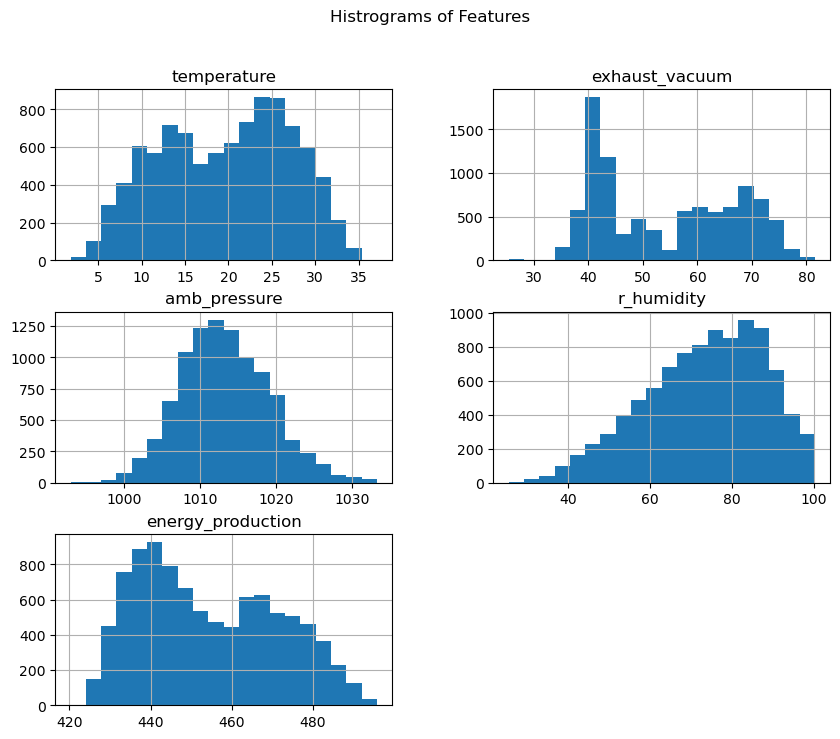

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

df.hist(bins=20, figsize=(10, 8))
plt.suptitle('Histrograms of Features')
plt.show()

**Box Plot**

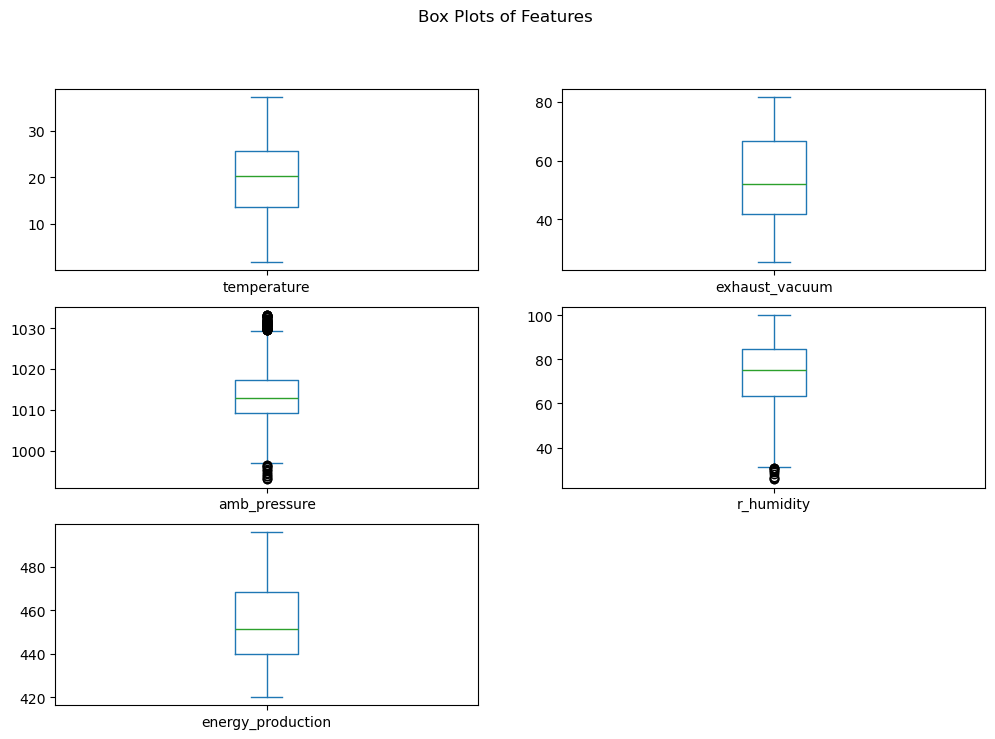

In [49]:
df.plot(kind='box', subplots=True, layout=(3,2), figsize=(12, 8), sharex=False, sharey=False)
plt.suptitle('Box Plots of Features')
plt.show()

**Correlation Heatmap**

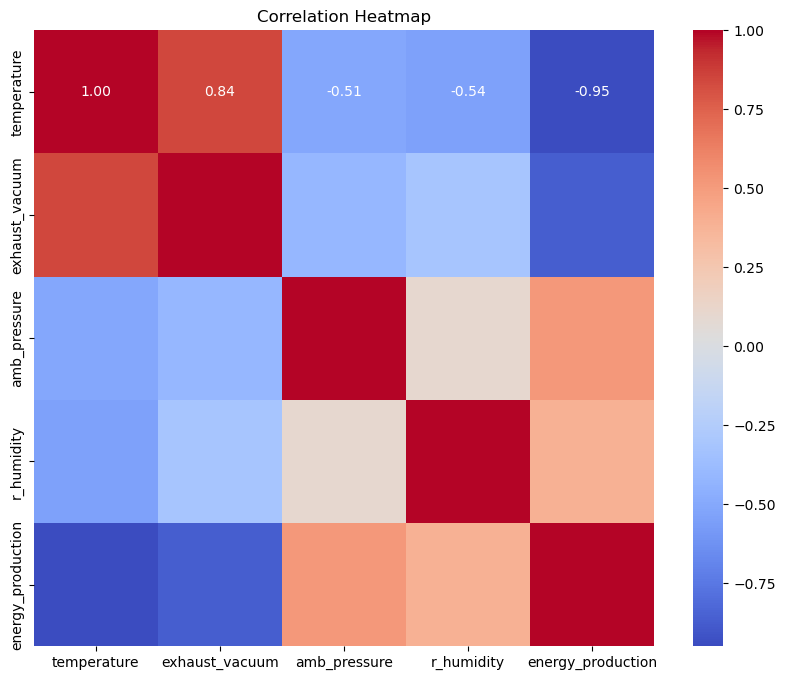

In [50]:
import seaborn as sns

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Pair Plot**

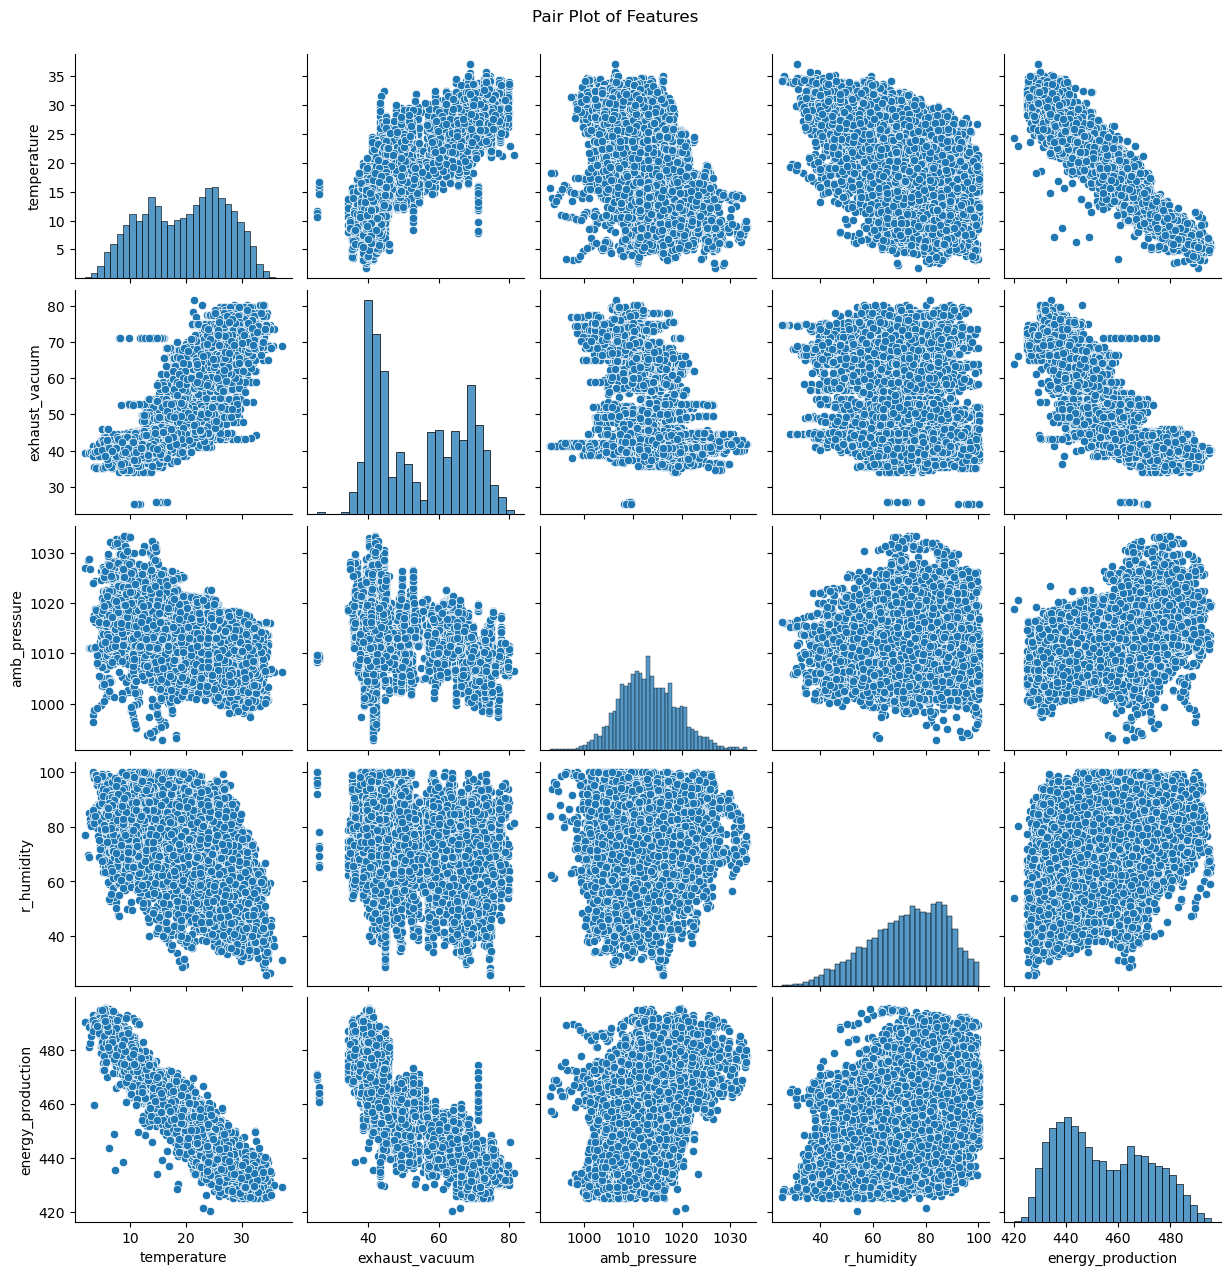

In [51]:
sns.pairplot(df)
plt.suptitle('Pair Plot of Features', y=1.02)
plt.show()

**Distribution Plot**

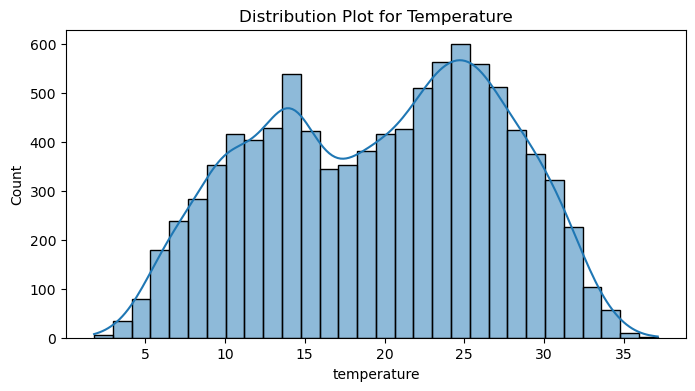

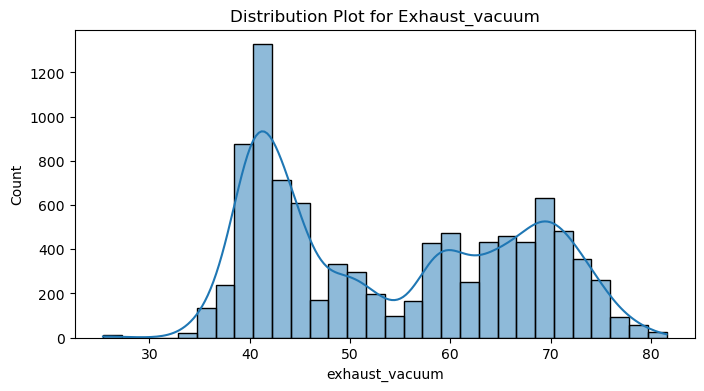

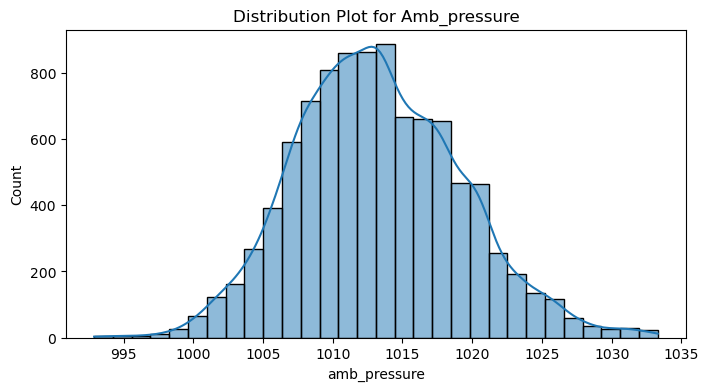

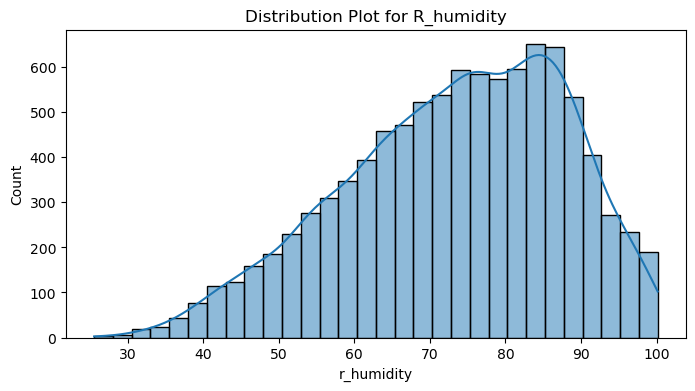

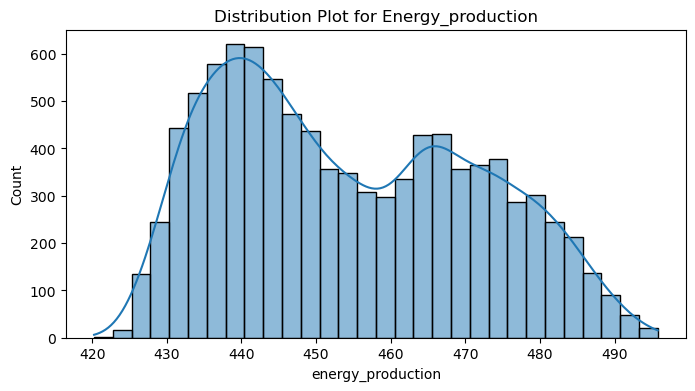

In [52]:
columns = ['temperature', 'exhaust_vacuum', 'amb_pressure', 'r_humidity', 'energy_production']

for col in columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution Plot for {col.capitalize()}')
    plt.show()
    

**Scatter Plot**

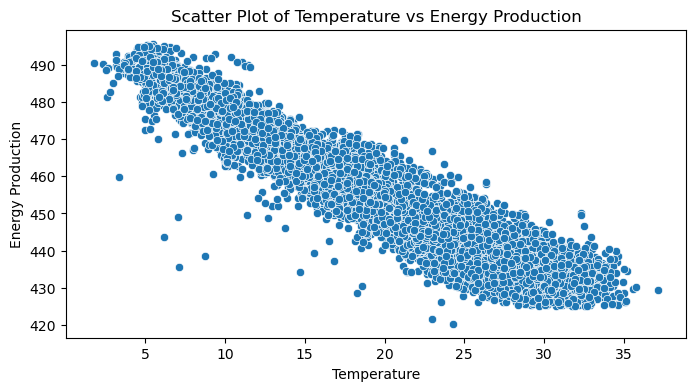

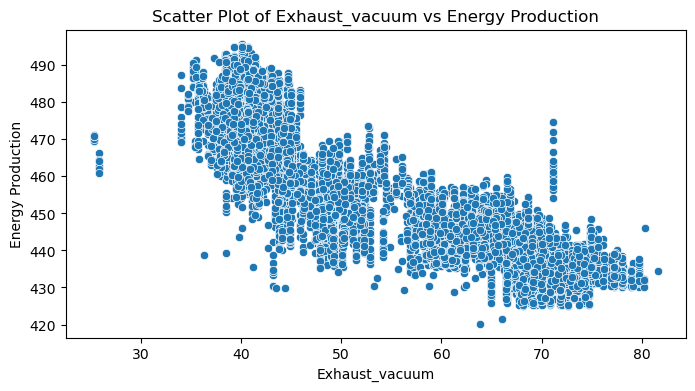

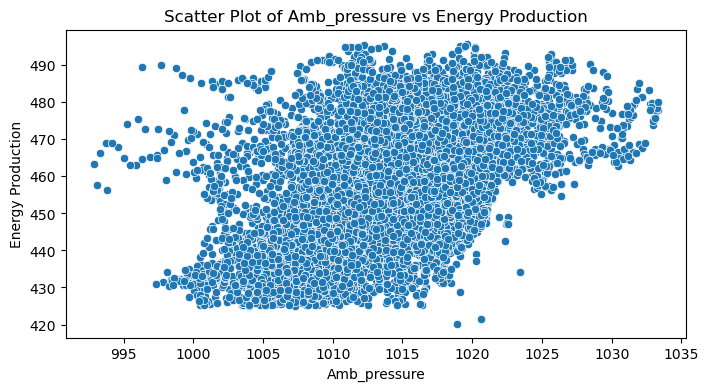

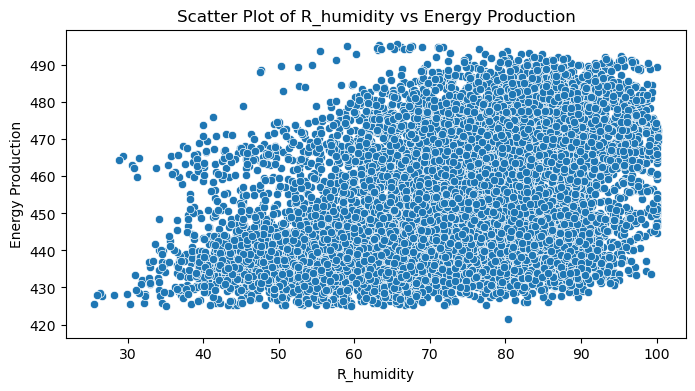

In [54]:
for col in columns[:-1]:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(x=df[col], y=df['energy_production'])
    plt.title(f'Scatter Plot of {col.capitalize()} vs Energy Production')
    plt.xlabel(f'{col.capitalize()}')
    plt.ylabel('Energy Production')
    plt.show()

**Feature Scaling**

In [57]:
from sklearn.preprocessing import StandardScaler

features = ['temperature', 'exhaust_vacuum', 'amb_pressure', 'r_humidity']
scaler = StandardScaler()
df_scaled = df_cleaned.copy()
df_scaled[features] = scaler.fit_transform(df_cleaned[features])
